In [1]:
import mne

epochs = mne.read_epochs("/Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball_MF_epochs_feedback_clean_beta-epo.fif", preload=True)
print(epochs)

Reading /Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball_MF_epochs_feedback_clean_beta-epo.fif ...
    Found the data of interest:
        t =    -199.22 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
715 matching events found
No baseline correction applied
0 projection items activated
<EpochsFIF | 715 events (all good), -0.199 – 0.801 s (baseline -0.2 – 0 s), ~95.4 MiB, data loaded,
 'loss': 261
 'reward': 454>


In [2]:
import mne
import numpy as np

# Start from clean, epoched data (feedback-locked)
# epochs: mne.Epochs, already re-referenced & cleaned

# --- Alpha band (8–12 Hz), posterior ROI ---
alpha_epochs = epochs.copy().filter(8., 12., fir_design="firwin")
alpha_epochs.apply_hilbert(envelope=True)  # analytic amplitude
alpha_data = alpha_epochs.get_data()       # (n_trials, n_channels, n_times)

alpha_roi = ['Oz', 'P1', 'PO3', 'PO7', 'PO8', 'O1', 'O2']
alpha_roi = [ch for ch in alpha_roi if ch in alpha_epochs.ch_names]
idx_alpha = [alpha_epochs.ch_names.index(ch) for ch in alpha_roi]

tmin, tmax = 0.0, 1.0  # post-feedback window
time_mask = (alpha_epochs.times >= tmin) & (alpha_epochs.times <= tmax)

alpha_env = alpha_data[:, idx_alpha, :][:, :, time_mask]
alpha_power_trial = alpha_env.mean(axis=(1, 2))  # one value per trial


Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 12.00 Hz
- Upper transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 13.50 Hz)
- Filter length: 423 samples (1.652 s)



/var/folders/bg/35xhpjxn5mn8n4n2k4h8pc8w0000gn/T/ipykernel_59420/391015983.py:8: RuntimeWarning: filter_length (423) is longer than the signal (257), distortion is likely. Reduce filter length or filter a longer signal.
  alpha_epochs = epochs.copy().filter(8., 12., fir_design="firwin")


In [3]:
# --- Beta band (13–30 Hz), sensorimotor ROI ---
beta_epochs = epochs.copy().filter(13., 30., fir_design="firwin")
beta_epochs.apply_hilbert(envelope=True)
beta_data = beta_epochs.get_data()

beta_roi = ['C3', 'Cz', 'C4', 'FC3', 'FCz', 'FC4', 'CP3', 'CPz', 'CP4']
beta_roi = [ch for ch in beta_roi if ch in beta_epochs.ch_names]
idx_beta = [beta_epochs.ch_names.index(ch) for ch in beta_roi]

beta_env = beta_data[:, idx_beta, :][:, :, time_mask]
beta_power_trial = beta_env.mean(axis=(1, 2))


Setting up band-pass filter from 13 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 13.00
- Lower transition bandwidth: 3.25 Hz (-6 dB cutoff frequency: 11.38 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 261 samples (1.020 s)



/var/folders/bg/35xhpjxn5mn8n4n2k4h8pc8w0000gn/T/ipykernel_59420/1781265358.py:2: RuntimeWarning: filter_length (261) is longer than the signal (257), distortion is likely. Reduce filter length or filter a longer signal.
  beta_epochs = epochs.copy().filter(13., 30., fir_design="firwin")


In [6]:
import pandas as pd
from scipy.stats import pearsonr

# 1) Load trajectories and keep participant 1
traj = pd.read_csv("trajectories.csv")
p1 = traj[traj["participant_id"] == "P001"].reset_index(drop=True)

V = p1["value_0"].to_numpy()      # expected value
PE = p1["prediction_error"].to_numpy()    # prediction error

# 2) Align lengths with EEG trials
n = min(len(V), len(alpha_power_trial), len(beta_power_trial))
V  = V[:n]
PE = PE[:n]
alpha_p = alpha_power_trial[:n]
beta_p  = beta_power_trial[:n]

# 3) Correlations EV/PE vs alpha/beta
r_ev_alpha, p_ev_alpha = pearsonr(V,  alpha_p)
r_pe_alpha, p_pe_alpha = pearsonr(PE, alpha_p)

r_ev_beta,  p_ev_beta  = pearsonr(V,  beta_p)
r_pe_beta,  p_pe_beta  = pearsonr(PE, beta_p)

print("EV–alpha:", r_ev_alpha, p_ev_alpha)
print("PE–alpha:", r_pe_alpha, p_pe_alpha)
print("EV–beta :", r_ev_beta,  p_ev_beta)
print("PE–beta :", r_pe_beta,  p_pe_beta)


EV–alpha: -0.051569896620337834 0.16837119734831243
PE–alpha: 0.008353448455003054 0.8235510918392723
EV–beta : -0.04696375972895277 0.20973965704788178
PE–beta : 0.018078744536550263 0.6293727290413642


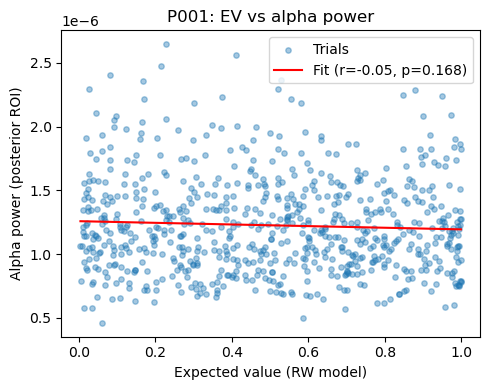

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Make sure lengths match
n = min(len(V), len(alpha_power_trial))
x = V[:n]
y = alpha_power_trial[:n]

# Fit linear regression y = a + b x
slope, intercept, r, p, stderr = linregress(x, y)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

plt.figure(figsize=(5, 4))
plt.scatter(x, y, s=15, alpha=0.4, label="Trials")
plt.plot(x_line, y_line, color="red",
         label=f"Fit (r={r:.2f}, p={p:.3f})")
plt.xlabel("Expected value (RW model)")
plt.ylabel("Alpha power (posterior ROI)")
plt.title("P001: EV vs alpha power")
plt.legend()
plt.tight_layout()
plt.show()
